In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentence = "transformers use self attention to understand relationships between words in a sentence"
words = sentence.split()
print(words)
print("Number of words:", len(words))

['transformers', 'use', 'self', 'attention', 'to', 'understand', 'relationships', 'between', 'words', 'in', 'a', 'sentence']
Number of words: 12


In [3]:
vocab = {word: idx for idx, word in enumerate(set(words))}
print(vocab)

{'relationships': 0, 'transformers': 1, 'understand': 2, 'between': 3, 'use': 4, 'attention': 5, 'words': 6, 'a': 7, 'sentence': 8, 'in': 9, 'to': 10, 'self': 11}


In [4]:
input_indices = torch.tensor([vocab[word] for word in words])
print(input_indices)

tensor([ 1,  4, 11,  5, 10,  2,  0,  3,  6,  9,  7,  8])


In [5]:
embedding_dim = 16
embedding = nn.Embedding(len(vocab), embedding_dim)
x = embedding(input_indices)
print("Embedding shape:", x.shape)

Embedding shape: torch.Size([12, 16])


In [6]:
d_model = embedding_dim
W_q = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, d_model)
W_v = nn.Linear(d_model, d_model)
Q = W_q(x)
K = W_k(x)
V = W_v(x)
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([12, 16])
K shape: torch.Size([12, 16])
V shape: torch.Size([12, 16])


In [7]:
scores = torch.matmul(Q, K.T)
print("Scores shape:", scores.shape)
print(scores)

Scores shape: torch.Size([12, 12])
tensor([[ 0.6896, -1.7192,  1.0673, -0.2114,  2.1608, -2.3925,  3.5977, -0.7948,
          0.4665, -2.2298, -1.6811, -0.8391],
        [-0.3349, -0.1528,  0.9120, -0.2516,  2.0507, -0.9633,  2.2371,  0.2486,
         -0.7264, -1.0268, -0.5474, -0.9996],
        [ 1.1010,  1.0060,  0.8040, -0.7758,  0.4793, -1.0361,  0.6544, -0.8182,
         -1.0383,  0.4695, -0.0366, -1.5988],
        [ 0.0456, -1.0535, -0.0053, -1.4679,  0.4499,  1.4444,  0.8287, -2.0259,
          1.3675,  0.8271,  0.7192, -1.4488],
        [ 0.2177,  0.1014,  2.5620,  2.0143, -0.3449, -1.3192,  3.1218,  1.9897,
         -0.4308, -1.7911, -0.9049, -0.6453],
        [ 0.9192,  0.4636,  0.8742, -1.9485,  0.1423,  0.6640,  0.9853, -1.9468,
          1.5956,  1.2358,  0.6724, -0.3603],
        [-0.3800, -0.8222,  0.5851,  1.0320,  1.1125, -0.7791,  2.5274,  0.8226,
          0.2350, -1.6118, -0.8746, -0.6063],
        [ 0.2995,  0.2644,  0.3211, -0.1004, -0.0226,  0.9808, -0.3259,  0.0

In [8]:
d_k = K.size(-1)
scaled_scores = scores / torch.sqrt( torch.tensor(d_k, dtype=torch.float32) )
print(scaled_scores)

tensor([[ 0.1724, -0.4298,  0.2668, -0.0529,  0.5402, -0.5981,  0.8994, -0.1987,
          0.1166, -0.5574, -0.4203, -0.2098],
        [-0.0837, -0.0382,  0.2280, -0.0629,  0.5127, -0.2408,  0.5593,  0.0621,
         -0.1816, -0.2567, -0.1369, -0.2499],
        [ 0.2753,  0.2515,  0.2010, -0.1939,  0.1198, -0.2590,  0.1636, -0.2045,
         -0.2596,  0.1174, -0.0092, -0.3997],
        [ 0.0114, -0.2634, -0.0013, -0.3670,  0.1125,  0.3611,  0.2072, -0.5065,
          0.3419,  0.2068,  0.1798, -0.3622],
        [ 0.0544,  0.0253,  0.6405,  0.5036, -0.0862, -0.3298,  0.7805,  0.4974,
         -0.1077, -0.4478, -0.2262, -0.1613],
        [ 0.2298,  0.1159,  0.2186, -0.4871,  0.0356,  0.1660,  0.2463, -0.4867,
          0.3989,  0.3089,  0.1681, -0.0901],
        [-0.0950, -0.2056,  0.1463,  0.2580,  0.2781, -0.1948,  0.6319,  0.2056,
          0.0587, -0.4029, -0.2186, -0.1516],
        [ 0.0749,  0.0661,  0.0803, -0.0251, -0.0057,  0.2452, -0.0815,  0.0146,
         -0.3262,  0.1978,  0.

In [9]:
attention_weights = F.softmax(scaled_scores, dim=-1)
print("Attention Weights:")
print(attention_weights)

Attention Weights:
tensor([[0.0928, 0.0508, 0.1020, 0.0741, 0.1341, 0.0430, 0.1920, 0.0640, 0.0878,
         0.0447, 0.0513, 0.0633],
        [0.0730, 0.0764, 0.0996, 0.0745, 0.1325, 0.0624, 0.1388, 0.0844, 0.0662,
         0.0614, 0.0692, 0.0618],
        [0.1088, 0.1063, 0.1011, 0.0681, 0.0932, 0.0638, 0.0973, 0.0674, 0.0638,
         0.0930, 0.0819, 0.0554],
        [0.0816, 0.0620, 0.0806, 0.0559, 0.0903, 0.1158, 0.0993, 0.0486, 0.1136,
         0.0993, 0.0966, 0.0562],
        [0.0739, 0.0718, 0.1329, 0.1159, 0.0642, 0.0503, 0.1528, 0.1151, 0.0629,
         0.0447, 0.0558, 0.0596],
        [0.0946, 0.0844, 0.0936, 0.0462, 0.0779, 0.0888, 0.0962, 0.0462, 0.1120,
         0.1024, 0.0890, 0.0687],
        [0.0709, 0.0635, 0.0903, 0.1010, 0.1030, 0.0642, 0.1467, 0.0958, 0.0827,
         0.0521, 0.0627, 0.0670],
        [0.0888, 0.0880, 0.0893, 0.0804, 0.0819, 0.1053, 0.0760, 0.0836, 0.0595,
         0.1004, 0.0980, 0.0487],
        [0.0795, 0.1016, 0.0478, 0.1201, 0.0520, 0.0854, 0.04

In [11]:
att_output = torch.matmul(attention_weights, V)
print("Attention Output shape:", att_output.shape)
print(att_output)

Attention Output shape: torch.Size([12, 16])
tensor([[-5.5699e-01,  7.5586e-02,  2.1446e-01, -1.5774e-01, -9.1743e-02,
         -4.0416e-01,  6.3837e-02, -4.5312e-02, -3.2337e-01, -1.8038e-01,
         -4.9314e-02, -3.8445e-01,  1.6916e-01,  3.7891e-01, -1.4943e-01,
          5.2964e-02],
        [-5.4626e-01, -3.9595e-04,  1.6880e-01, -6.0894e-02, -7.9711e-02,
         -3.7851e-01, -4.9764e-02,  4.2368e-02, -2.5387e-01, -1.9457e-01,
         -1.4125e-01, -4.2035e-01,  1.4227e-01,  3.4699e-01, -1.8229e-01,
          9.7443e-02],
        [-4.9129e-01, -2.1651e-03,  1.2877e-01,  2.0080e-02, -9.2384e-02,
         -3.8417e-01, -1.0662e-01,  5.5689e-02, -1.7859e-01, -1.3394e-01,
         -2.7309e-01, -3.4166e-01,  2.1564e-01,  2.9557e-01, -1.5821e-01,
         -2.1065e-02],
        [-4.3986e-01, -6.9800e-03,  1.1464e-01,  9.8686e-02, -7.7998e-02,
         -3.9438e-01, -1.1593e-01,  2.9844e-02, -3.4569e-02, -7.8749e-02,
         -3.6433e-01, -3.8146e-01,  1.4619e-01,  3.2515e-01, -1.4639e-01

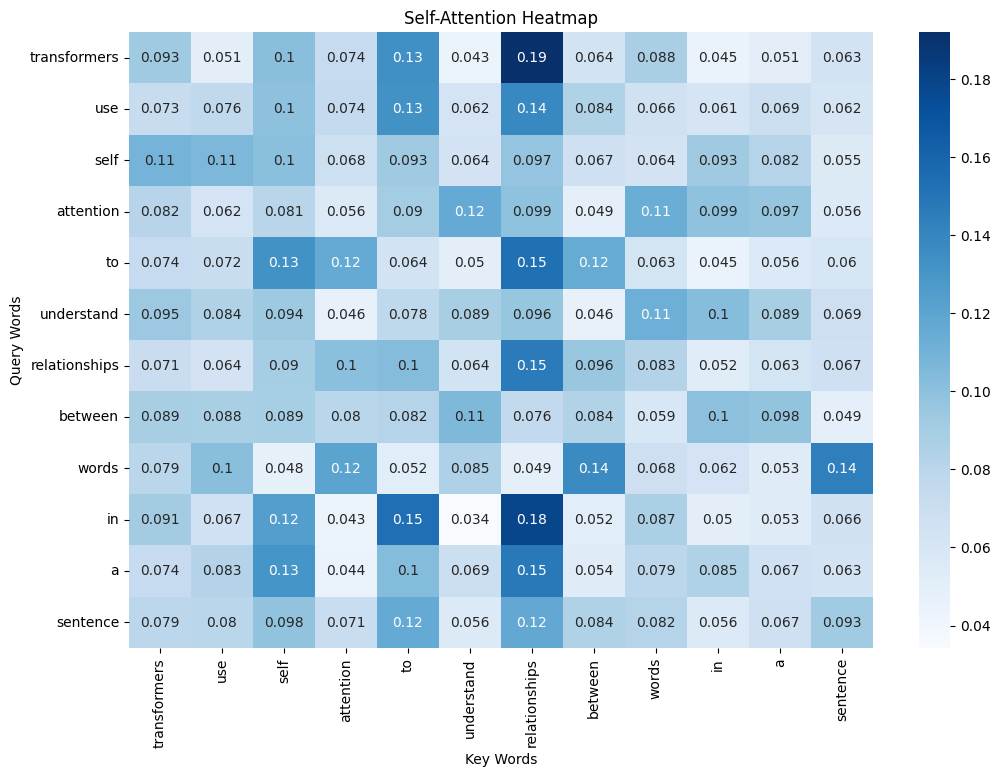

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap( attention_weights.detach().numpy(), xticklabels=words, yticklabels=words, cmap="Blues", annot=True )
plt.title("Self-Attention Heatmap")
plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.show()

In [30]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        assert self.head_dim * num_heads == d_model

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, x):

        seq_length = x.shape[0]

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(seq_length, self.num_heads, self.head_dim)
        K = K.view(seq_length, self.num_heads, self.head_dim)
        V = V.view(seq_length, self.num_heads, self.head_dim)

        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        attention = F.softmax(
            scores / np.sqrt(self.head_dim),
            dim=-1
        )

        out = torch.matmul(attention, V)

        out = out.reshape(seq_length, self.d_model)

        out = self.fc_out(out)

        return out, attention


mha = MultiHeadAttention(
    d_model=16,
    num_heads=4
)

mha_output, mha_attention = mha(x)

print(mha_output.shape)
print(mha_attention.shape)

torch.Size([12, 16])
torch.Size([12, 4, 4])


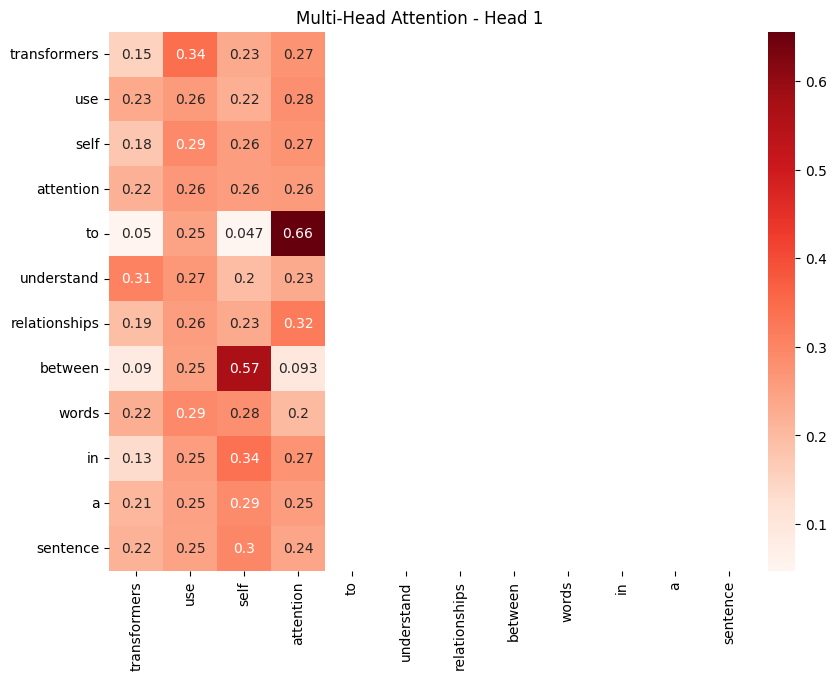

In [31]:
head_1 = mha_attention[:, 0, :].detach().numpy()
plt.figure(figsize=(10, 7))
sns.heatmap( head_1, xticklabels=words, yticklabels=words, cmap="Reds", annot=True )
plt.title("Multi-Head Attention - Head 1")
plt.show()

In [32]:
class FeedForward(nn.Module):
  def __init__(self, d_model):
    super().__init__()
    self.fc1 = nn.Linear(d_model, 64)
    self.fc2 = nn.Linear(64, d_model)
  def forward(self, x):
    x = F.relu(self.fc1(x))

    x = self.fc2(x)
    return x

In [33]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.mha = MultiHeadAttention( d_model, num_heads )
    self.norm1 = nn.LayerNorm(d_model)
    self.ff = FeedForward(d_model)
    self.norm2 = nn.LayerNorm(d_model)
  def forward(self, x):
      attention_output, attention_weights = self.mha(x)
      x = self.norm1(x + attention_output)
      ff_output = self.ff(x)
      x = self.norm2(x + ff_output)
      return x, attention_weights

In [34]:
encoder = TransformerEncoderBlock( d_model=16, num_heads=4 )
encoder_output, encoder_attention = encoder(x)
print("Encoder Output shape:")
print(encoder_output.shape)

Encoder Output shape:
torch.Size([12, 16])


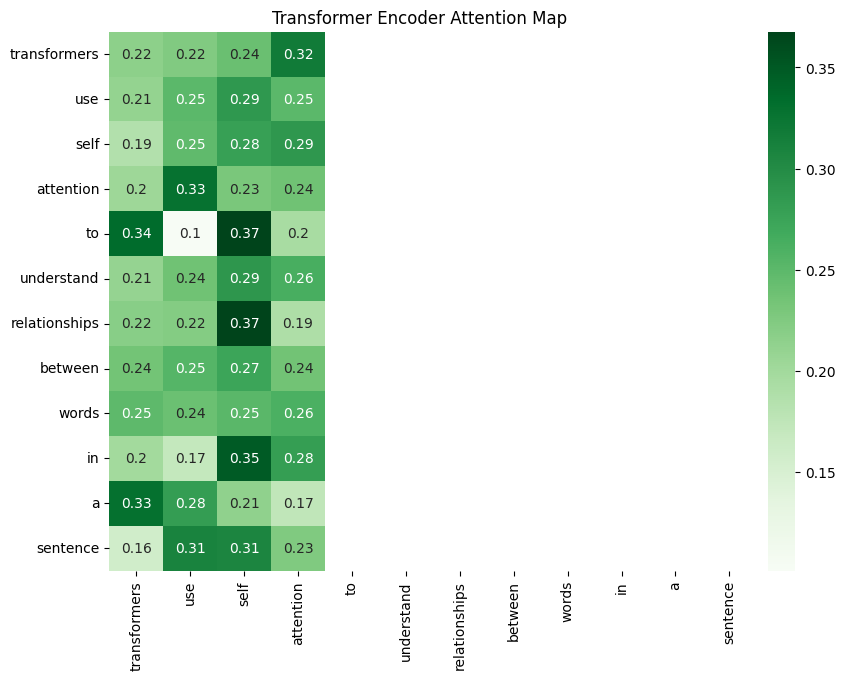

In [35]:
encoder_head = encoder_attention[:, 0, :].detach().numpy()
plt.figure(figsize=(10, 7))
sns.heatmap( encoder_head, xticklabels=words, yticklabels=words, cmap="Greens", annot=True )
plt.title("Transformer Encoder Attention Map")
plt.show()

In [37]:
encoder_layer = nn.TransformerEncoderLayer( d_model=16, nhead=4 )
pytorch_encoder = nn.TransformerEncoder( encoder_layer, num_layers=1 )
x_batch = x.unsqueeze(1)
output = pytorch_encoder(x_batch)
print("PyTorch Encoder Output shape:")
print(output.shape)

PyTorch Encoder Output shape:
torch.Size([12, 1, 16])


/tmp/ipykernel_2318/2911126280.py:2: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  pytorch_encoder = nn.TransformerEncoder( encoder_layer, num_layers=1 )


Қорытынды

Self-Attention механизмі

Self-Attention сөйлемдегі сөздердің бір-бірімен байланысын анықтайды. Әр сөз басқа сөздерге назар аударады және олардың маңыздылығын attention weights арқылы есептейді.

Multi-Head Attention механизмі

Multi-Head Attention бірнеше attention head қолдану арқылы әртүрлі байланыстарды үйренеді. Әр head мәтіндегі әртүрлі тәуелділіктерді анықтай алады.




| Критерий            | Өз реализациям | PyTorch Transformer |
| ------------------- | -------------- | ------------------- |
| Код көлемі          | Ұзын           | Қысқа               |
| Түсініктілік        | Жоғары         | Орташа              |
| Икемділік           | Жоғары         | Орташа              |
| Орындау жылдамдығы  | Баяу           | Жылдам              |
| Қолдану ыңғайлылығы | Орташа         | Жоғары              |

Жалпы қорытынды

Transformer архитектурасындағы Self-Attention және Multi-Head Attention механизмдері мәтіндегі сөздер арасындағы маңызды байланыстарды анықтауға мүмкіндік береді. Бұл механизмдер қазіргі заманғы NLP модельдерінің негізгі компоненттерінің бірі болып табылады.